# Ionosphere Data Processing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from tqdm import tqdm


# Load the energy efficiency dataset
data = pd.read_csv('./2024_ionosphere_data.csv', header=None)

# Separate features and target
X = data.iloc[:, :34].values
# print(X.shape)
Y = data.iloc[:, -1].values
Y = (Y == 'g').astype(int) # let g = 1 and b = 0
# print(Y.shape)


# Function to split data into train and test sets
def train_test_split(X, Y, test_rate=0.2):
    n = X.shape[0]
    # print("n: ", n)
    test_size = int(n * test_rate)
    # print("test_size: ", test_size)
    indices = range(n)
    # print("indices: ", indices)
    training_idx, test_idx = indices[test_size:], indices[:test_size]
    # print("tr_idx: ", training_idx.shape, ", test_idx: ", test_idx.shape)
    return X[training_idx], X[test_idx], Y[training_idx], Y[test_idx]

# Split the data into training (75%) and testing (25%) sets
X_train, X_test, y_train, y_test = train_test_split(X, Y)

# Function to normalize features
def normalize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0) + 1e-8
    return (X - mean) / std, mean, std

# Normalize the features
# X_train, train_mean, train_std = normalize(X_train)
# X_test = (X_test - train_mean) / train_std

print("Data loaded and preprocessed.")
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Data loaded and preprocessed.
Training set shape: (281, 34)
Test set shape: (70, 34)


In [115]:
config = {
    'layers_dims': [X_train.shape[1], 64, 64, 32, 1], # Input layer, hidden layers, output layer
    'learning_rate': 1e-5,
    'num_epochs': 10000,
    'batch_size': 32
}

# Ionosphere Neural Network Core



In [116]:
# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
    # print("np.exp(-np.clip(x, -500, 500): ", np.exp(-np.clip(x[0][0], -500, 500)))
    # return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_derivative(x):
    x = sigmoid(x)
    return x * (1 - x)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float) 
    # if x > 0, return 1, otherwise return 0
    # use astype(float) to convert boolean to float, to avoid any probability of error in calculation
    
def cross_entropy_loss(Y, y_pred):
    # if(-np.mean(Y * np.log(y_pred + 1e-8) + (1 - Y) * np.log(1 - y_pred + 1e-8)) >= 1e+8):
    #     print("too big")
    epsilon = 1e-8
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(Y * np.log(y_pred) + (1 - Y) * np.log(1 - y_pred))

def cross_entropy_loss_derivative(Y, AL):
    epsilon = 1e-8
    AL = np.clip(AL, epsilon, 1 - epsilon)
    # print("AL: ", AL)
    return -Y/AL + (1 - Y)/(1 - AL)

In [117]:
class Net:
    def __init__(self, layers_dims=config['layers_dims']):
        
        np.random.seed(321)
        self.parameters = {}
        L = len(layers_dims)

        for l in range(1, L):
            self.parameters[f'W{l}'] = np.random.randn(layers_dims[l], layers_dims[l-1]) * np.sqrt(2 / layers_dims[l-1])
            self.parameters[f'b{l}'] = np.zeros((layers_dims[l], 1))

    
    def forward(self, X):
        # Forward propagation
        self.cache = {}
        A = X
        # print("A.shape: ", A.shape, "X.shape: ", X.shape)
        L = len(self.parameters) // 2 # Number of layers in the neural network, since parameters of one layer contain W and b
        self.cache[f'A0'] = A
        # self.cache[f'Z0'] = X

        for l in range(1, L): # only 1 to L-1 layers
            Z = np.dot(self.parameters[f'W{l}'], A) + self.parameters[f'b{l}'] # Z = W * A + b
            self.cache[f'Z{l}'] = Z
            A = relu(Z)
            self.cache[f'A{l}'] = A
        ZL = np.dot(self.parameters[f'W{L}'], A) + self.parameters[f'b{L}'] # the last layer (L), not included in the for loop
        AL = sigmoid(ZL)  # activation function is not needed for the regression problem
        # print("AL.shape: ", AL.shape)
        self.cache[f'A{L}'] = AL
        self.cache[f'Z{L}'] = ZL

        return AL
    
    def backward(self, AL, Y):
        self.grads = {}
        L = len(self.parameters) // 2
        m = Y.shape[1] # number of data (batch size)
        Y = Y.reshape(AL.shape) # make sure Y has the same shape as AL

        # gradient of the output layer
        
        dZL = cross_entropy_loss_derivative(Y, AL) * sigmoid_derivative(self.cache[f'Z{L}'])
        # print("CE derivative: ", cross_entropy_loss_derivative(Y, AL))
        '''
            J = -np.mean(Y * np.log(AL) + (1 - Y) * np.log(1 - AL))
            dJ/dZL = dJ/dAL * dAL/dZL = -Y/AL + (1 - Y)/(1 - AL) * sigmoid_derivative(ZL)
        '''
        self.grads[f'dW{L}'] = np.dot(dZL, self.cache[f'A{L-1}'].T) # dJ/dW = dJ/dZ * dZ/dW
        self.grads[f'db{L}'] = np.sum(dZL, axis=1, keepdims=True)
        '''
            since ZL = W * AL-1 + b, gradient of b (dJ/db) = dJ/dZL * dZL/db, dZL/db = 1
            therefore, dJ/db = dJ/dZL = AL - Y. is the same as gradient of W
        '''
        dA = np.dot(self.parameters[f'W{L}'].T, dZL)

        # gradient of the hidden layers
        for l in reversed(range(1, L)): # from L-1 to 1
            dZ = dA * relu_derivative(self.cache[f'Z{l}']) # A = relu(Z), dJ/dZ = dJ/dA * dA/dZ = dA * relu_derivative(Z)
            self.grads[f'dW{l}'] = np.dot(dZ, self.cache[f'A{l-1}'].T)
            self.grads[f'db{l}'] = np.sum(dZ, axis=1, keepdims=True)

            # if np.any(self.grads[f'dW{l}'] == 0):
            #     # print("gradiente is 0, dZ: ", dZ, ", cache[f'A{l-1}']: ", cache[f'A{l-1}'].T)
            #     exit()

            if l > 1:
                dA = np.dot(self.parameters[f'W{l}'].T, dZ)

            '''
                W{l} is the weight matrix of this layer, dZ{l} is the gradient of this layer
                J = 1/2m * sum{(AL - Y)^2}, Z = W * A + b, dA = dJ/dA = dZ/dA * dJ/dZ, dZ/dA = W
                therefore, dA = W{l}.T * dZ, is the gradient of last layer
                * the Transpose of W is because Z = W*A + b, when we calculate dA, we need to calculate it opposite way, so we need to transpose W
            '''
        
        # update weights and biases
        for l in range(1, L + 1):
            self.parameters[f'W{l}'] -= config['learning_rate'] * self.grads[f'dW{l}']
            self.parameters[f'b{l}'] -= config['learning_rate'] * self.grads[f'db{l}']
            
                    
    def compute_loss(self, X, Y):
        y_pred = self.forward(X)
        # m = Y.shape[1]
        loss = cross_entropy_loss(Y, y_pred)
        # print("cross_entropy: ", loss)
        return loss
    
    def train(self, X, Y):
        loss_history = []

        num_batches = X.shape[1] // config['batch_size']
    
        for i in range(config['num_epochs']):
            for j in range(num_batches):
                start_idx = j * config['batch_size']
                end_idx = start_idx + config['batch_size']
                X_batch = X[:, start_idx:end_idx]
                Y_batch = Y[:, start_idx:end_idx]

                AL = self.forward(X_batch)
                self.backward(AL, Y_batch)

            # if i % 100 == 0:
            loss = self.compute_loss(X, Y)
            loss_history.append(loss)
            # if i % 50 == 0:
            print(f"Loss in epoch {i}: {loss}")
        
        return loss_history
    
    def run_model(self, X):
        AL = self.forward(X)
        return AL
    
    def forward_latent_layers(self, X):
        # Forward propagation
        A = X
        L = len(self.parameters) // 2 # Number of layers in the neural network, since parameters of one layer contain W and b
        # self.cache[f'Z0'] = X

        for l in range(1, L): # only 1 to L-1 layers
            Z = np.dot(self.parameters[f'W{l}'], A) + self.parameters[f'b{l}'] # Z = W * A + b
            A = relu(Z)
        ZL = np.dot(self.parameters[f'W{L}'], A) + self.parameters[f'b{L}'] # the last layer (L), not included in the for loop
        AL = sigmoid(ZL)  # activation function is not needed for the regression problem
        # AL = (AL >= 0.5).astype(int)
        # print("A.shape: ", A.shape)
        return A, AL

print("Neural Network class defined.")

model = Net()

Neural Network class defined.


# Training Process


In [118]:
# Train the model
print("Training the model...")
loss_history = model.train(X_train.T, y_train.reshape(1, -1))

print("Model training completed.")

Training the model...
Loss in epoch 0: 0.8285587408002458
Loss in epoch 1: 0.8201071989688139
Loss in epoch 2: 0.8122277628377339
Loss in epoch 3: 0.8048915477534708
Loss in epoch 4: 0.7979957725962766
Loss in epoch 5: 0.7915573122758615
Loss in epoch 6: 0.7855207058793882
Loss in epoch 7: 0.7798504150583989
Loss in epoch 8: 0.7745010283485539
Loss in epoch 9: 0.7694492209321658
Loss in epoch 10: 0.7646443059494604
Loss in epoch 11: 0.760081092669786
Loss in epoch 12: 0.7557572598412374
Loss in epoch 13: 0.751666923973007
Loss in epoch 14: 0.7477839165988529
Loss in epoch 15: 0.7440866439919988
Loss in epoch 16: 0.7405664429551608
Loss in epoch 17: 0.737215865911027
Loss in epoch 18: 0.7340254815790704
Loss in epoch 19: 0.730981360578547
Loss in epoch 20: 0.7280694366589991
Loss in epoch 21: 0.7252834628371686
Loss in epoch 22: 0.7226043502610123
Loss in epoch 23: 0.7200268538628979
Loss in epoch 24: 0.7175394779626403
Loss in epoch 25: 0.7151485545679581
Loss in epoch 26: 0.7128284316

# Model Evaluation and Visualization 

Training Error Rate: 0.0214
Test Error Rate: 0.0857
last loss:  0.05371372477319951


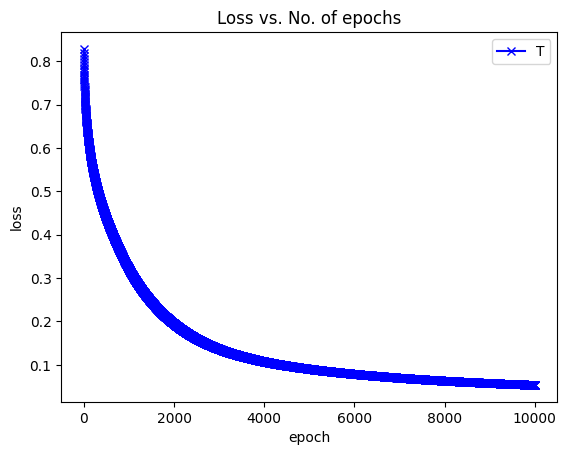

In [119]:
# Make predictions
y_train_pred = model.run_model(X_train.T).flatten()
y_test_pred = model.run_model(X_test.T).flatten()

def get_error_rate(y_true, y_pred):
    y_pred = (y_pred > 0.5).astype(int)
    return np.mean(y_true != y_pred)

train_error = get_error_rate(y_train, y_train_pred)
test_error = get_error_rate(y_test, y_test_pred)

print(f"Training Error Rate: {train_error:.4f}")
print(f"Test Error Rate: {test_error:.4f}")

# Visualize learning curve
def plot_losses(loss_history):
  plt.plot(loss_history, '-bx')
  plt.xlabel('epoch')
  plt.ylabel('loss')
  plt.legend('Training')
  plt.title('Loss vs. No. of epochs')

plot_losses(loss_history)
print("last loss: ", loss_history[-1])

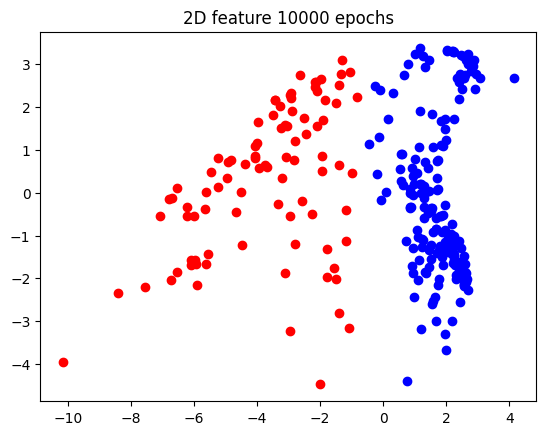

In [120]:
def pca(X, n_components=2):
    # 1. Standardize the data (mean = 0 for each feature)
    X_meaned = X - np.mean(X, axis=0)
    
    # 2. Compute the covariance matrix
    cov_matrix = np.cov(X_meaned, rowvar=False)
    
    # 3. Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # 4. Sort eigenvalues and select the top n components
    sorted_index = np.argsort(eigenvalues)[::-1]
    sorted_eigenvectors = eigenvectors[:, sorted_index]
    
    # 5. Select the subset of eigenvectors (n_components)
    eigenvector_subset = sorted_eigenvectors[:, 0:n_components]
    
    # 6. Transform the data to the new subspace
    X_reduced = np.dot(X_meaned, eigenvector_subset)
    
    return X_reduced


latent_features, result = model.forward_latent_layers(X_train.T)
# print("latent_features.shape: ", latent_features.shape)

X_pca = pca(latent_features.T, 2)

g_indices = np.where(result > 0.5)[1]  # Indices for first group
b_indices = np.where(result <= 0.5)[1]  # Indices for second group
# print("g: ", g_indices.shape, ", b: ", b_indices.shape)
'''
# use library to do PCA
from sklearn.decomposition import PCA
X_pca = PCA(n_components = 2)
X_transformed = X_pca.fit_transform(latent_features.T)
# print("X_transformed: ", X_transformed.shape)
plt.scatter(X_transformed[g_indices, 0], X_transformed[g_indices, 1], label="g", c='blue')
plt.scatter(X_transformed[b_indices, 0], X_transformed[b_indices, 1], label="b", c='red')
'''

plt.scatter(X_pca[g_indices, 0], X_pca[g_indices, 1], label="g", c='blue')
plt.scatter(X_pca[b_indices, 0], X_pca[b_indices, 1], label="b", c='red')

plt.title(f'2D feature {config["num_epochs"]} epochs')
plt.show()
